# Logistic Regression Experiments — Top 15 Features

All experiments use the **top 15 most important features** (from Random Forest)
to keep the model simple and interpretable.

**Experiments:**
1. Default LogisticRegression (L2)
2. class_weight='balanced'
3. Stronger class weight (2x balanced)
4. L1 penalty (Lasso) + balanced
5. Lower C (stronger regularization)
6. SMOTE + LogisticRegression
7. SMOTE + class_weight='balanced'

Each reports per-class recall at default, F1-optimal, and F2-optimal thresholds.

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, precision_recall_curve,
    average_precision_score, recall_score, precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print('Imports OK')

Imports OK


## 1. Data loading & preprocessing

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    'mlg-ulb/creditcardfraud',
    'creditcard.csv'
)

print(f"Dataset shape: {df.shape}")
print(f"Fraud ratio: {df['Class'].mean():.4%}")

new_df = df.copy()
new_df['Amount'] = RobustScaler().fit_transform(new_df['Amount'].to_numpy().reshape(-1, 1))
new_df['Time']   = StandardScaler().fit_transform(new_df[['Time']])
new_df = new_df.sample(frac=1, random_state=42)

train, temp = train_test_split(new_df, test_size=0.2, stratify=new_df['Class'], random_state=42)
test,  val  = train_test_split(temp,   test_size=0.5, stratify=temp['Class'],   random_state=42)

x_train = train.drop(columns=['Class']); y_train = train['Class']
x_test  = test.drop(columns=['Class']);  y_test  = test['Class']
x_val   = val.drop(columns=['Class']);   y_val   = val['Class']

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")
print(f"Val fraud count: {y_val.sum()} / {len(y_val)}")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset shape: (284807, 31)
Fraud ratio: 0.1727%
Train: (227845, 30), Val: (28481, 30), Test: (28481, 30)
Val fraud count: 49 / 28481


## 2. Top 15 features (RF importance)

In [4]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(x_train, y_train)

importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
top15 = x_train.columns[sorted_idx[:15]]

print("Top 15 features:", list(top15))

x_train_15 = x_train[top15]
x_val_15   = x_val[top15]
x_test_15  = x_test[top15]

print(f"\nShapes: train {x_train_15.shape}, val {x_val_15.shape}, test {x_test_15.shape}")

Top 15 features: ['V14', 'V10', 'V12', 'V4', 'V17', 'V3', 'V11', 'V16', 'V2', 'V9', 'V21', 'V7', 'V19', 'V20', 'V18']

Shapes: train (227845, 15), val (28481, 15), test (28481, 15)


## 3. Evaluation helper

In [5]:
results = []

def evaluate(name, y_true, y_proba):
    prec_arr, rec_arr, thr_arr = precision_recall_curve(y_true, y_proba)
    n = len(thr_arr)
    eps = 1e-9
    f1 = np.array([2*prec_arr[j+1]*rec_arr[j+1] / (prec_arr[j+1]+rec_arr[j+1]+eps) for j in range(n)])
    f2 = np.array([5*prec_arr[j+1]*rec_arr[j+1] / (4*prec_arr[j+1]+rec_arr[j+1]+eps) for j in range(n)])
    pr_auc = average_precision_score(y_true, y_proba)

    pred_def = (y_proba >= 0.5).astype(int)
    j1 = np.argmax(f1)
    pred_f1 = (y_proba >= thr_arr[j1]).astype(int)
    j2 = np.argmax(f2)
    pred_f2 = (y_proba >= thr_arr[j2]).astype(int)

    for label, pred in [('default (0.5)', pred_def), (f'F1-opt ({thr_arr[j1]:.4f})', pred_f1), (f'F2-opt ({thr_arr[j2]:.4f})', pred_f2)]:
        results.append({
            'Experiment': name, 'Threshold': label,
            'Precision (fraud)': precision_score(y_true, pred),
            'Recall (fraud)': recall_score(y_true, pred),
            'Recall (legit)': recall_score(y_true, pred, pos_label=0),
            'F1 (fraud)': f1_score(y_true, pred), 'PR-AUC': pr_auc
        })

    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"\n--- Default (0.5) ---")
    print(classification_report(y_true, pred_def, target_names=['Legit (0)', 'Fraud (1)']))
    print(f"--- F1-opt ({thr_arr[j1]:.4f}) ---")
    print(classification_report(y_true, pred_f1, target_names=['Legit (0)', 'Fraud (1)']))
    print(f"--- F2-opt ({thr_arr[j2]:.4f}) ---")
    print(classification_report(y_true, pred_f2, target_names=['Legit (0)', 'Fraud (1)']))
    return y_proba

print('evaluate() ready')

evaluate() ready


## 4. Experiment 1 — Default LogisticRegression (L2)

In [6]:
lr1 = LogisticRegression(max_iter=1000, random_state=42)
lr1.fit(x_train_15, y_train)
evaluate('1. LR default (L2)', y_val, lr1.predict_proba(x_val_15)[:, 1])


1. LR default (L2)
PR-AUC: 0.7730

--- Default (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.85      0.59      0.70        49

    accuracy                           1.00     28481
   macro avg       0.93      0.80      0.85     28481
weighted avg       1.00      1.00      1.00     28481

--- F1-opt (0.0318) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.77      0.84      0.80        49

    accuracy                           1.00     28481
   macro avg       0.89      0.92      0.90     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-opt (0.0318) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.77      0.84      0.80        49

    accuracy                           1.00     28481
   macro avg       0.8

array([0.00012357, 0.00068681, 0.00026202, ..., 0.00050154, 0.00051121,
       0.00096488])

## 5. Experiment 2 — class_weight='balanced'

In [7]:
lr2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr2.fit(x_train_15, y_train)
evaluate('2. LR balanced', y_val, lr2.predict_proba(x_val_15)[:, 1])


2. LR balanced
PR-AUC: 0.6939

--- Default (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      0.98      0.99     28432
   Fraud (1)       0.06      0.86      0.11        49

    accuracy                           0.98     28481
   macro avg       0.53      0.92      0.55     28481
weighted avg       1.00      0.98      0.99     28481

--- F1-opt (0.9990) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.76      0.76      0.76        49

    accuracy                           1.00     28481
   macro avg       0.88      0.88      0.88     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-opt (0.9910) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.63      0.82      0.71        49

    accuracy                           1.00     28481
   macro avg       0.82   

array([0.04357698, 0.12786392, 0.03045964, ..., 0.07641882, 0.09938619,
       0.50401715])

## 6. Experiment 3 — Stronger class weight (2x balanced ratio)

In [8]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
weight_2x = {0: 1.0, 1: 2 * (neg / pos)}

lr3 = LogisticRegression(max_iter=1000, class_weight=weight_2x, random_state=42)
lr3.fit(x_train_15, y_train)
evaluate('3. LR 2x class weight', y_val, lr3.predict_proba(x_val_15)[:, 1])


3. LR 2x class weight
PR-AUC: 0.6798

--- Default (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      0.95      0.97     28432
   Fraud (1)       0.03      0.88      0.06        49

    accuracy                           0.95     28481
   macro avg       0.51      0.91      0.52     28481
weighted avg       1.00      0.95      0.97     28481

--- F1-opt (0.9998) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.72      0.73      0.73        49

    accuracy                           1.00     28481
   macro avg       0.86      0.87      0.86     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-opt (0.9967) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.59      0.82      0.68        49

    accuracy                           1.00     28481
   macro avg       

array([0.0795797 , 0.22125337, 0.05914577, ..., 0.13359743, 0.17377798,
       0.65751856])

## 7. Experiment 4 — L1 penalty (Lasso) + balanced

In [9]:
lr4 = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, class_weight='balanced', random_state=42)
lr4.fit(x_train_15, y_train)
evaluate('4. LR L1 (saga) balanced', y_val, lr4.predict_proba(x_val_15)[:, 1])


4. LR L1 (saga) balanced
PR-AUC: 0.6939

--- Default (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      0.98      0.99     28432
   Fraud (1)       0.06      0.86      0.11        49

    accuracy                           0.98     28481
   macro avg       0.53      0.92      0.55     28481
weighted avg       1.00      0.98      0.99     28481

--- F1-opt (0.9990) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.76      0.76      0.76        49

    accuracy                           1.00     28481
   macro avg       0.88      0.88      0.88     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-opt (0.9909) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.63      0.82      0.71        49

    accuracy                           1.00     28481
   macro avg    

array([0.04357151, 0.12785127, 0.03045233, ..., 0.07640807, 0.09939383,
       0.50422625])

## 8. Experiment 5 — Lower C (stronger regularization)

In [10]:
for C in [0.01, 0.1, 1.0]:
    lr = LogisticRegression(C=C, max_iter=1000, class_weight='balanced', random_state=42)
    lr.fit(x_train_15, y_train)
    evaluate(f'5. LR C={C} balanced', y_val, lr.predict_proba(x_val_15)[:, 1])


5. LR C=0.01 balanced
PR-AUC: 0.6889

--- Default (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      0.98      0.99     28432
   Fraud (1)       0.06      0.86      0.11        49

    accuracy                           0.98     28481
   macro avg       0.53      0.92      0.55     28481
weighted avg       1.00      0.98      0.99     28481

--- F1-opt (0.9990) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.76      0.76      0.76        49

    accuracy                           1.00     28481
   macro avg       0.88      0.88      0.88     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-opt (0.9866) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.62      0.82      0.70        49

    accuracy                           1.00     28481
   macro avg       

## 9. Experiment 6 — SMOTE + LogisticRegression

In [11]:
for ratio in [0.2, 0.3, 0.5]:
    pipe = ImbPipeline([
        ('smote', SMOTE(sampling_strategy=ratio, k_neighbors=5, random_state=42)),
        ('lr', LogisticRegression(max_iter=1000, random_state=42))
    ])
    pipe.fit(x_train_15, y_train)
    evaluate(f'6. SMOTE {ratio} + LR', y_val, pipe.predict_proba(x_val_15)[:, 1])


6. SMOTE 0.2 + LR
PR-AUC: 0.7421

--- Default (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      0.99      1.00     28432
   Fraud (1)       0.21      0.86      0.34        49

    accuracy                           0.99     28481
   macro avg       0.61      0.93      0.67     28481
weighted avg       1.00      0.99      1.00     28481

--- F1-opt (0.9725) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.79      0.78      0.78        49

    accuracy                           1.00     28481
   macro avg       0.90      0.89      0.89     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-opt (0.8924) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.73      0.84      0.78        49

    accuracy                           1.00     28481
   macro avg       0.87

## 10. Experiment 7 — SMOTE + class_weight='balanced'

In [12]:
pipe7 = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.3, k_neighbors=5, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
pipe7.fit(x_train_15, y_train)
evaluate('7. SMOTE 0.3 + LR balanced', y_val, pipe7.predict_proba(x_val_15)[:, 1])


7. SMOTE 0.3 + LR balanced
PR-AUC: 0.6984

--- Default (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      0.97      0.99     28432
   Fraud (1)       0.05      0.86      0.10        49

    accuracy                           0.97     28481
   macro avg       0.53      0.92      0.54     28481
weighted avg       1.00      0.97      0.99     28481

--- F1-opt (0.9992) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.74      0.76      0.75        49

    accuracy                           1.00     28481
   macro avg       0.87      0.88      0.87     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-opt (0.9880) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.56      0.86      0.68        49

    accuracy                           1.00     28481
   macro avg  

array([0.03568123, 0.11139701, 0.0319365 , ..., 0.07676819, 0.0932202 ,
       0.48755714])

## 11. Results summary

In [13]:
results_df = pd.DataFrame(results)
for col in ['Precision (fraud)', 'Recall (fraud)', 'Recall (legit)', 'F1 (fraud)', 'PR-AUC']:
    results_df[col] = results_df[col].round(4)

print('=== F2-OPTIMAL (sorted by Fraud Recall) ===\n')
f2 = results_df[results_df['Threshold'].str.startswith('F2')].sort_values('Recall (fraud)', ascending=False)
print(f2.to_string(index=False))

best = f2.iloc[0]
print(f"\n*** Best: {best['Experiment']} — Recall (fraud)={best['Recall (fraud)']:.4f}, Precision={best['Precision (fraud)']:.4f}, PR-AUC={best['PR-AUC']:.4f}")

=== F2-OPTIMAL (sorted by Fraud Recall) ===

                Experiment       Threshold  Precision (fraud)  Recall (fraud)  Recall (legit)  F1 (fraud)  PR-AUC
         6. SMOTE 0.5 + LR F2-opt (0.9614)             0.6000          0.8571          0.9990      0.7059  0.7070
7. SMOTE 0.3 + LR balanced F2-opt (0.9880)             0.5600          0.8571          0.9988      0.6774  0.6984
        1. LR default (L2) F2-opt (0.0318)             0.7736          0.8367          0.9996      0.8039  0.7730
         6. SMOTE 0.2 + LR F2-opt (0.8924)             0.7321          0.8367          0.9995      0.7810  0.7421
         6. SMOTE 0.3 + LR F2-opt (0.9344)             0.7069          0.8367          0.9994      0.7664  0.7271
     3. LR 2x class weight F2-opt (0.9967)             0.5882          0.8163          0.9990      0.6838  0.6798
            2. LR balanced F2-opt (0.9910)             0.6349          0.8163          0.9992      0.7143  0.6939
      5. LR C=1.0 balanced F2-opt (0.9910) 

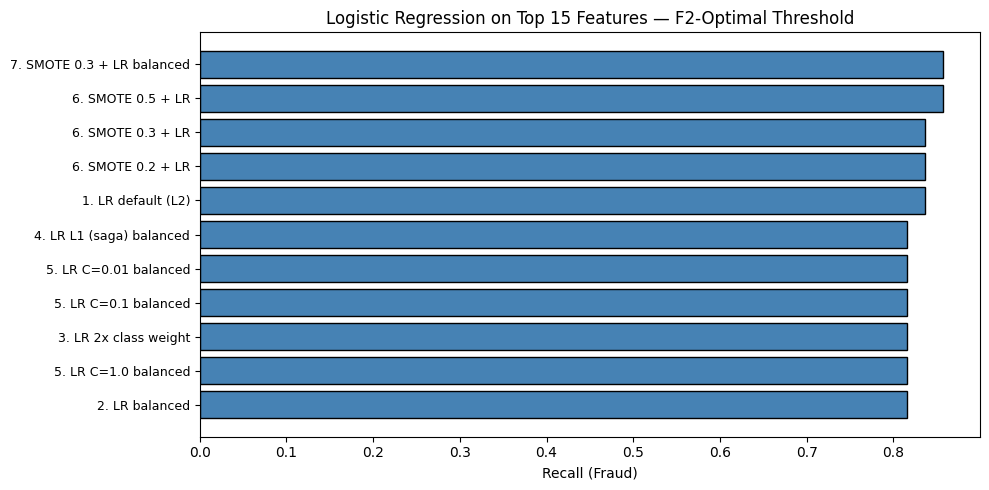

In [14]:
import matplotlib.pyplot as plt

f2_plot = f2.sort_values('Recall (fraud)', ascending=True)
fig, ax = plt.subplots(figsize=(10, max(5, len(f2_plot)*0.3)))
y_pos = range(len(f2_plot))
ax.barh(y_pos, f2_plot['Recall (fraud)'], color='steelblue', edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(f2_plot['Experiment'], fontsize=9)
ax.set_xlabel('Recall (Fraud)')
ax.set_title('Logistic Regression on Top 15 Features — F2-Optimal Threshold')
plt.tight_layout()
plt.show()